In [1]:
from pyspark.sql import SparkSession

spark = (
        SparkSession.builder
        .appName("fintek_analytics")
        .master("spark://spark-master:7077")

        .config("spark.executor.memory", "2g")
        .config("spark.driver.memory", "1g")
        .config("spark.executor.cores", 2)
        .config("spark.sql.shuffle.partitions", 10)

        .config("spark.driver.host", "fintek-jupyter")
        .config("spark.driver.bindAddress", "0.0.0.0")

        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.3")

        .getOrCreate()
    )

:: loading settings :: url = jar:file:/opt/conda/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/jovyan/.ivy2.5.2/cache
The jars for the packages stored in: /home/jovyan/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-4fe0e8a7-8030-4487-87ba-c087c7ae328b;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.3 in central
	found org.checkerframework#checker-qual;3.42.0 in central
:: resolution report :: resolve 74ms :: artifacts dl 2ms
	:: modules in use:
	org.checkerframework#checker-qual;3.42.0 from central in [default]
	org.postgresql#postgresql;42.7.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------

In [2]:
jdbc_url = "jdbc:postgresql://fintek-postgres:5432/fintek_db"

properties = {
    "user": "finance",
    "password": "finance123",
    "driver": "org.postgresql.Driver"
}

try:
    print("Veriler veritabanından okunuyor...")
    
    sql_prices = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            p.price_time,
            p.close,
            a.asset_type
        FROM prices p
        JOIN assets a
            ON p.asset_id = a.asset_id
        WHERE p.price_time >= '2024-01-01'
    ) AS index_prices
    """,
    properties=properties
)
    sql_returns = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            r.return_time,
            r.log_return,
            a.asset_type
        FROM returns r
        JOIN assets a
            ON r.asset_id = a.asset_id
        WHERE r.return_time >= '2024-01-01'
    ) AS index_returns
    """,
    properties=properties
)

    print("\n--- Prices ---")
    sql_prices.show(5)

    print("\n--- Returns ---")
    sql_returns.show(5)

except Exception as e:
    print(f"Veritabanına bağlanırken bir hata oluştu: {e}")

Veriler veritabanından okunuyor...

--- Prices ---


+------+----------+------------------+----------+
|ticker|price_time|             close|asset_type|
+------+----------+------------------+----------+
|  AAPL|2024-01-02|183.73130798339844|    equity|
|  MSFT|2024-01-02|364.58941650390625|    equity|
|  NVDA|2024-01-02|48.138572692871094|    equity|
|  AMZN|2024-01-02|149.92999267578125|    equity|
| GOOGL|2024-01-02|137.03741455078125|    equity|
+------+----------+------------------+----------+
only showing top 5 rows

--- Returns ---
+------+-----------+--------------------+----------+
|ticker|return_time|          log_return|asset_type|
+------+-----------+--------------------+----------+
|  AAPL| 2024-01-02|-0.03644279815750...|    equity|
|  MSFT| 2024-01-02|-0.01384411882653...|    equity|
|  NVDA| 2024-01-02|-0.02772218214267...|    equity|
|  AMZN| 2024-01-02|-0.01331725248741...|    equity|
| GOOGL| 2024-01-02|-0.01094085152441...|    equity|
+------+-----------+--------------------+----------+
only showing top 5 rows


In [3]:
import pandas as pd
import numpy as np

print("🚀 Spark verileri Pandas formatına dönüştürülüyor...")

df_prices = sql_prices.toPandas()
df_returns = sql_returns.toPandas()

print("Veriler ayrıştırılıyor ve Pivot tablolara dönüştürülüyor...")

df_prices['price_time'] = pd.to_datetime(df_prices['price_time'])
df_returns['return_time'] = pd.to_datetime(df_returns['return_time'])

df_prices_indices = df_prices[df_prices['asset_type'] == 'index'].copy()
df_prices_stocks = df_prices[df_prices['asset_type'] == 'equity'].copy()

df_returns_indices = df_returns[df_returns['asset_type'] == 'index'].copy()
df_returns_stocks = df_returns[df_returns['asset_type'] == 'equity'].copy()

prices_index_pivot = df_prices_indices.pivot(
    index='price_time', columns='ticker', values='close'
).sort_index()

prices_stock_pivot = df_prices_stocks.pivot(
    index='price_time', columns='ticker', values='close'
).sort_index()

returns_index_pivot = df_returns_indices.pivot(
    index='return_time', columns='ticker', values='log_return'
).sort_index()

returns_stock_pivot = df_returns_stocks.pivot(
    index='return_time', columns='ticker', values='log_return'
).sort_index()

prices_index_pivot.columns.name = None
prices_stock_pivot.columns.name = None
returns_index_pivot.columns.name = None
returns_stock_pivot.columns.name = None

prices_index_pivot.index.name = None
prices_stock_pivot.index.name = None
returns_index_pivot.index.name = None
returns_stock_pivot.index.name = None


print("\n--- ENDEKS GETİRİLERİ (PİVOT - Saf Sayısal) ---")
print(returns_index_pivot.head())

print("\n--- HİSSE GETİRİLERİ (PİVOT - Saf Sayısal) ---")
print(returns_stock_pivot.head())

🚀 Spark verileri Pandas formatına dönüştürülüyor...
Veriler ayrıştırılıyor ve Pivot tablolara dönüştürülüyor...

--- ENDEKS GETİRİLERİ (PİVOT - Saf Sayısal) ---
                 DJI    NASDAQ     SP500
2024-01-02  0.000676 -0.016483 -0.005677
2024-01-03 -0.007581 -0.011835 -0.008049
2024-01-04  0.000271 -0.005629 -0.003434
2024-01-05  0.000688  0.000949  0.001824
2024-01-08  0.005773  0.021773  0.014016

--- HİSSE GETİRİLERİ (PİVOT - Saf Sayısal) ---
                AAPL      AMZN       BAC     GOOGL        GS       JPM  \
2024-01-02 -0.036443 -0.013317  0.006808 -0.010941  0.006537  0.011573   
2024-01-03 -0.007516 -0.009786 -0.010974  0.005413 -0.016907 -0.004368   
2024-01-04 -0.012781 -0.026619  0.008020 -0.018380  0.003034  0.006614   
2024-01-05 -0.004021  0.004624  0.018467 -0.004851  0.009072  0.005005   
2024-01-08  0.023887  0.026230 -0.007873  0.022655  0.006243 -0.001452   

                MSFT      NVDA  
2024-01-02 -0.013844 -0.027722  
2024-01-03 -0.000728 -0.012514  
2

🚀 Etkin Sınır (Efficient Frontier) hesaplaması başlıyor...


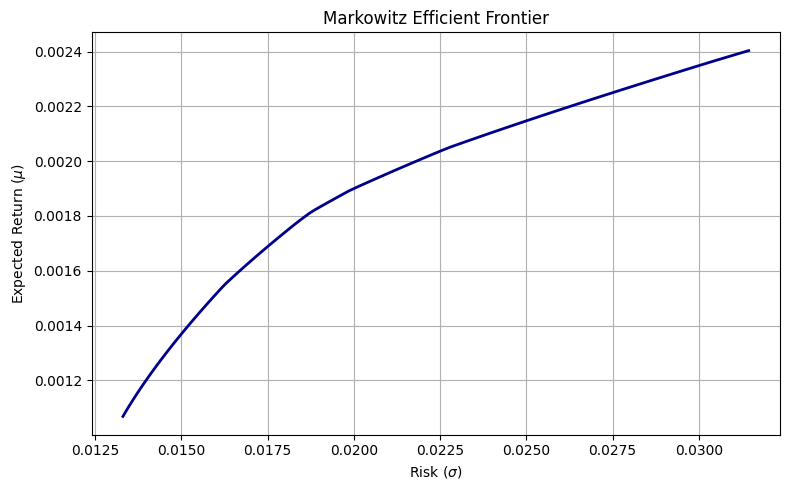


--- Etkin Sınır Risk (Standart Sapma) Değerleri (İlk 5 nokta) ---
[0.01331064 0.01337255 0.01343694 0.01350264 0.01356965]

--- Etkin Sınır Beklenen Getiri Değerleri (İlk 5 nokta) ---
[0.00106805 0.00108154 0.00109503 0.00110852 0.00112202]


In [4]:
import os
import sys

sys.path.append(os.path.abspath('..')) 

from src.frontier import p_frontier

print("🚀 Etkin Sınır (Efficient Frontier) hesaplaması başlıyor...")

veri_frontier = returns_stock_pivot

frontier_sonuclari = p_frontier(veri_frontier, step=0.01, plot=True)

print("\n--- Etkin Sınır Risk (Standart Sapma) Değerleri (İlk 5 nokta) ---")
print(frontier_sonuclari["Risk"][:5])

print("\n--- Etkin Sınır Beklenen Getiri Değerleri (İlk 5 nokta) ---")
print(frontier_sonuclari["Return"][:5])

In [25]:
import os
import sys

sys.path.append(os.path.abspath('..')) 

from src.p_optim import p_optim

print("🚀 Optimizasyon başlıyor...")

results = p_optim(returns_stock_pivot)

print("\n--- İstatistikler ---")
print(results["stats"])

print("\n--- Optimal Ağırlıklar (Max Sharpe) ---")
print(results["weights"].loc["Max_Sharpe"])

print("\n--- Optimal Ağırlıklar (Min Risk) ---")
print(results["weights"].loc["Min_Risk"])

🚀 Optimizasyon başlıyor...

--- İstatistikler ---
         Type    Sharpe    Return     Risk
0  Max Sharpe  0.098480  0.001322  0.01342
1    Min Risk  0.060016  0.000688  0.01147

--- Optimal Ağırlıklar (Max Sharpe) ---
AAPL     0.0569
AMZN     0.0000
BAC      0.0246
GOOGL    0.3353
GS       0.0939
JPM      0.3955
MSFT     0.0000
NVDA     0.0938
Name: Max_Sharpe, dtype: float64

--- Optimal Ağırlıklar (Min Risk) ---
AAPL     0.1383
AMZN     0.0000
BAC      0.1619
GOOGL    0.1195
GS       0.0000
JPM      0.2406
MSFT     0.3397
NVDA     0.0000
Name: Min_Risk, dtype: float64


In [61]:
max_sharpe_weights = results["weights"].loc["Max_Sharpe"]

portfoy_getirisi = returns_stock_pivot.dot(max_sharpe_weights)

sharpe_port = portfoy_getirisi.to_frame(name="Max Sharpe Portföyü")

print("\n--- Max Sharpe Portföyü Günlük Getirileri ---")
print(portfoy_returns_df.head())


--- Max Sharpe Portföyü Günlük Getirileri ---
            Max Sharpe Portföyü
2024-01-02            -0.002984
2024-01-03            -0.003371
2024-01-04            -0.002950
2024-01-05             0.003554
2024-01-08             0.014617


In [72]:
import os
import sys

sys.path.append(os.path.abspath('..')) 

from src.p_stat import p_stats
for endeks_adi in endeks_tum.columns:
    
    p_stats(
        data_var=varliklar, 
        data_index=endeks_tum[[endeks_adi]], 
        weights=max_sharpe_weights,
        caption=f"Market Benchmark: {endeks_adi}"
    )
    print("-" * 50)

,Beta,Beta (Mid %90),Beta (Low %5),Beta (High %5),Treynor Ratio,VaR (%5)
Portfolio,1.16,0.94,1.30,1.40,0.0011,2.00%
AAPL,1.13,0.86,1.94,1.98,0.0005,2.75%
AMZN,1.26,1.14,1.13,1.51,0.0005,2.89%
BAC,1.21,0.96,1.88,0.93,0.0006,2.30%
GOOGL,0.87,0.64,0.70,1.22,0.0017,2.61%
GS,1.62,1.47,1.60,1.67,0.0009,2.48%
JPM,1.23,1.07,1.54,1.20,0.0009,2.29%
MSFT,0.85,0.68,0.58,1.26,0.0002,2.39%
NVDA,1.43,0.95,1.63,2.36,0.0017,4.58%


--------------------------------------------------


,Beta,Beta (Mid %90),Beta (Low %5),Beta (High %5),Treynor Ratio,VaR (%5)
Portfolio,0.86,0.72,1.11,0.84,0.0015,2.00%
AAPL,0.88,0.75,1.92,1.34,0.0007,2.75%
AMZN,1.12,1.17,0.64,1.13,0.0006,2.89%
BAC,0.59,0.37,1.83,0.60,0.0013,2.30%
GOOGL,0.91,0.90,0.48,0.73,0.0016,2.61%
GS,0.89,0.67,1.71,1.02,0.0017,2.48%
JPM,0.59,0.33,1.37,0.72,0.0018,2.29%
MSFT,0.80,0.87,0.37,0.82,0.0002,2.39%
NVDA,1.83,1.88,1.00,1.27,0.0013,4.58%


--------------------------------------------------


,Beta,Beta (Mid %90),Beta (Low %5),Beta (High %5),Treynor Ratio,VaR (%5)
Portfolio,1.17,1.10,1.10,1.08,0.0011,2.00%
AAPL,1.18,0.95,1.61,1.69,0.0005,2.75%
AMZN,1.42,1.47,0.71,1.34,0.0004,2.89%
BAC,0.96,0.75,1.68,0.73,0.0008,2.30%
GOOGL,1.11,1.14,0.52,0.94,0.0013,2.61%
GS,1.34,1.21,1.54,1.30,0.0011,2.48%
JPM,0.96,0.76,1.39,0.95,0.0011,2.29%
MSFT,1.00,1.08,0.36,1.06,0.0002,2.39%
NVDA,2.17,2.44,1.02,1.63,0.0011,4.58%


--------------------------------------------------


In [7]:
spark.stop()